# Chapter 4 - Predicting House Prices (Regression)

Not every problem is classification: sometimes the answer is a **number** -- the median temperature, the stock price, or the median home value of a neighborhood.

Regression predicts a continuous number. At the end of the network you need:
- a **single unit** output with **no activation**,
- `mean_squared_error` (MSE) or `mean_absolute_error` (MAE) as the loss.

In this chapter we do everything from scratch: `numpy` generates a synthetic housing dataset with a known ground-truth rule, then we train a regressor to recover it.

## 1. Why "from scratch"?
The classic Boston-Housing dataset was removed from Keras 3. A synthetic dataset is actually more educational here: **we know the exact rule** the network must discover, so we can judge how well it recovers it.

Hidden rule for the price of a house:
price = 50 + 1.0*size + 30*bedrooms - 0.8*age + 15*near_transport + noise

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers, models

print("Keras", keras.__version__)
np.random.seed(42)

Keras 3.15.1


In [2]:
n_samples = 2000
n_features = 5

# Feature scales are wildly different on purpose (size ~30-250, age 0-80, beds 1-5)
X = np.zeros((n_samples, n_features))
X[:, 0] = np.random.uniform(30, 250, n_samples)   # size (m2)
X[:, 1] = np.random.randint(1, 6, n_samples)      # bedrooms
X[:, 2] = np.random.randint(0, 80, n_samples)     # age (years)
X[:, 3] = np.random.randint(0, 2, n_samples)      # near transport (0/1)
X[:, 4] = np.random.uniform(0, 1, n_samples)      # garden quality

y = (50 + 1.0 * X[:, 0] + 30 * X[:, 1] - 0.8 * X[:, 2] + 15 * X[:, 3]
     + np.random.normal(0, 20, n_samples))

print("X", X.shape, "| y range:", round(y.min()), "-", round(y.max()))

X (2000, 5) | y range: 42 - 507


## 2. Split + normalize (z-score, computed on training only)

In [3]:
def split_normalize(X, y, train_ratio=0.8, seed=0):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X))
    split = int(len(X) * train_ratio)
    tr, te = idx[:split], idx[split:]
    mean = X[tr].mean(axis=0); std = X[tr].std(axis=0) + 1e-8
    return (X[tr]-mean)/std, (X[te]-mean)/std, y[tr], y[te]

X_tr, X_te, y_tr, y_te = split_normalize(X, y)
print("train", X_tr.shape, "test", X_te.shape)

train (1600, 5) test (400, 5)


## 3. Build the regression model

In [4]:
def build_model():
    model = models.Sequential([
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),  # no activation => regression output
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_tr, y_tr, validation_data=(X_te, y_te),
                    epochs=60, batch_size=64, verbose=1)

Epoch 1/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 15s 629ms/step - loss: 68601.0469 - mae: 247.6713

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 72458.1328 - mae: 255.6411 - val_loss: 70431.7734 - val_mae: 252.8806


Epoch 2/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 66223.8750 - mae: 243.0097

...

 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 595.5900 - mae: 19.3531

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 687.9420 - mae: 20.9154 - val_loss: 707.9426 - val_mae: 20.9062


Epoch 60/60


 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 703.9430 - mae: 21.2892

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 678.9055 - mae: 20.7821 - val_loss: 700.9678 - val_mae: 20.8244


## 4. Review the curves & the error in dollars (MAE)

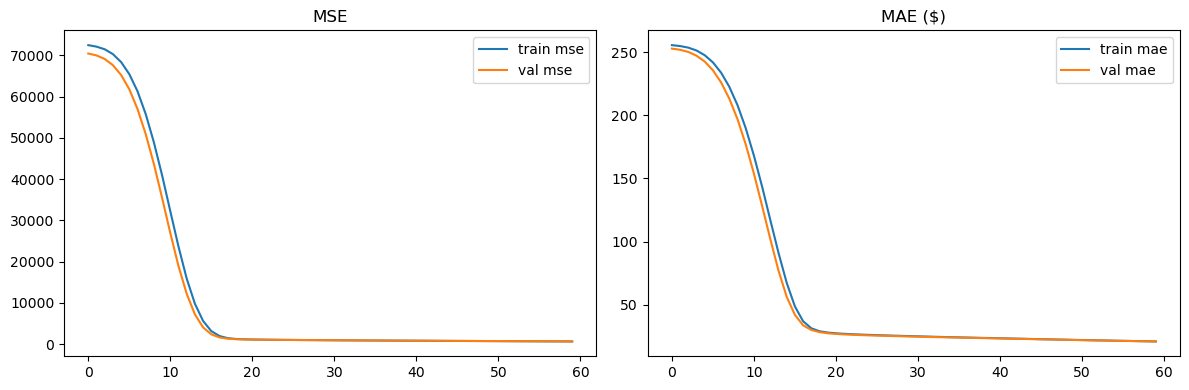

In [6]:
def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history["loss"], label="train mse")
    ax[0].plot(history.history["val_loss"], label="val mse")
    ax[0].legend(); ax[0].set_title("MSE")
    ax[1].plot(history.history["mae"], label="train mae")
    ax[1].plot(history.history["val_mae"], label="val mae")
    ax[1].legend(); ax[1].set_title("MAE ($)")
    plt.tight_layout(); plt.show()

plot_history(history)

In [7]:
val_mae = history.history["val_mae"][-1]
print(f"final validation MAE ~ ${val_mae:.0f}k")

final validation MAE ~ $21k


## 5. K-fold cross validation -> an honest, stable error number
One random split is noisy (look at the wiggles above). K-fold retrains the model K times on different 80/20 splits and averages the held-out error. This is the number to quote.

In [8]:
from sklearn.model_selection import KFold

k = 4
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, te_idx) in enumerate(kf.split(X)):
    Xtr2, Xte2, ytr2, yte2 = split_normalize(X[tr_idx], y[tr_idx])
    m = build_model()
    m.fit(Xtr2, ytr2, validation_data=(Xte2, yte2), epochs=40, batch_size=32, verbose=0)
    _, mae = m.evaluate(Xte2, yte2, verbose=0)
    fold_scores.append(mae)
    print(f"fold {fold+1}: MAE = ${mae:.0f}k")

print(f"\nCV mean MAE ~ ${np.mean(fold_scores):.0f}k")

fold 1: MAE = $21k


fold 2: MAE = $22k


fold 3: MAE = $21k


fold 4: MAE = $20k

CV mean MAE ~ $21k


## Recap
- Regression nets end with one linear output unit + `mse` loss; `mae` is the interpretable metric ("off by $Xk on average").
- **Normalize features** so mixed-scale columns (size vs age) train stably.
- **K-fold CV** gives a far more stable error estimate than one random split - especially on small datasets.